### 1. Environment & Device Setup

In [1]:
import os
import json
import time
from pathlib import Path
import torch
from tabulate import tabulate
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device.upper()}")
print(f"PyTorch Version: {torch.__version__}")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Rajat\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Device: CPU
PyTorch Version: 2.14.0+cpu


### 2. Verify Dataset Paths & Configuration

In [2]:
base_dir = Path(".").resolve()
dataset_yaml = base_dir / "SLD_YOLO_Dataset" / "data.yaml"
output_dir = base_dir / "results" / "yolo"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Dataset YAML: {dataset_yaml}")
print(f"Output Dir:   {output_dir}")

with open(dataset_yaml, 'r', encoding='utf-8') as f:
    print(f.read())

Dataset YAML: D:\HOSHO\Model Testing\SLD_YOLO_Dataset\data.yaml
Output Dir:   D:\HOSHO\Model Testing\results\yolo
# SLD Symbol Detection Dataset - YOLO11 & YOLO Format
path: d:/HOSHO/Model Testing/SLD_YOLO_Dataset
train: images/train
val: images/valid
test: images/test

names:
  0: SINGLE PHASE UNFUSED TAP OFF UNIT
  1: ZERO PHASE SEQUENCE CURRENT TRANSFORMER

nc: 2



### 3. Initialize YOLO11 Architecture

In [ ]:

model = YOLO('yolo11n.pt')
print("Loaded YOLO11 model weights successfully!")

Loaded YOLO11 model weights successfully!


### 4. Train Model on SLD Drawings

In [4]:
print("Starting YOLO11 Training...")
start_train_time = time.time()

train_results = model.train(
    data=str(dataset_yaml),
    epochs=15,               
    imgsz=640,
    batch=4,
    workers=2,
    device=device,
    project=str(output_dir),
    name="train_run",
    seed=42,
    exist_ok=True,
    plots=True,
    verbose=True
)

train_duration = time.time() - start_train_time
print(f"Training finished in {train_duration / 60.0:.2f} minutes!")

Starting YOLO11 Training...
Ultralytics 8.4.173  Python-3.14.7 torch-2.14.0+cpu CPU (Intel Core 5 120U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\HOSHO\Model Testing\SLD_YOLO_Dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_run, nbs=64, 

### 5. Evaluate on Unseen TEST Split

In [5]:
print("Evaluating on Unseen Test Split...")
test_metrics = model.val(
    data=str(dataset_yaml),
    split="test",
    device=device,
    plots=True
)

map50 = float(test_metrics.box.map50)
map50_95 = float(test_metrics.box.map)
precision = float(test_metrics.box.mp)
recall = float(test_metrics.box.mr)
f1 = float(2 * (precision * recall) / (precision + recall + 1e-6))
inference_latency = float(test_metrics.speed.get("inference", 0.0))

per_class_maps = test_metrics.box.maps if hasattr(test_metrics.box, 'maps') else [0, 0]
tap_off_map = float(per_class_maps[0]) if len(per_class_maps) > 0 else 0.0
zct_map = float(per_class_maps[1]) if len(per_class_maps) > 1 else 0.0


metrics_summary = {
    "model_name": "YOLO11 Nano",
    "architecture": "One-Stage CNN + Attention Head",
    "mAP50": map50,
    "mAP50_95": map50_95,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "tap_off_unit_ap50": tap_off_map,
    "zct_sensor_ap50": zct_map,
    "inference_latency_ms": inference_latency,
    "train_time_minutes": train_duration / 60.0
}

metrics_file = output_dir / "yolo_metrics.json"
with open(metrics_file, "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)

table_data = [
    ["Model Architecture", metrics_summary["model_name"]],
    ["mAP@50", f"{map50:.4f}"],
    ["mAP@50:95", f"{map50_95:.4f}"],
    ["Precision", f"{precision:.4f}"],
    ["Recall", f"{recall:.4f}"],
    ["F1-Score", f"{f1:.4f}"],
    ["Tap-Off Unit AP@50", f"{tap_off_map:.4f}"],
    ["ZCT Sensor AP@50", f"{zct_map:.4f}"],
    ["Inference Latency", f"{inference_latency:.2f} ms / image"],
    ["Training Duration", f"{train_duration / 60.0:.2f} mins"]
]

print("\n" + tabulate(table_data, headers=["Metric / Parameter", "YOLO11 Result"], tablefmt="fancy_grid"))

Evaluating on Unseen Test Split...
Ultralytics 8.4.173  Python-3.14.7 torch-2.14.0+cpu CPU (Intel Core 5 120U)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 180.129.3 MB/s, size: 218.1 KB)
val: Scanning D:\HOSHO\Model Testing\SLD_YOLO_Dataset\labels\test... 36 images, 24 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 1.1Kit/s 0.0s
val: New cache created: D:\HOSHO\Model Testing\SLD_YOLO_Dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.7s/it 5.1s4.3ss
                   all         36         17      0.491      0.633      0.549      0.265
SINGLE PHASE UNFUSED TAP OFF UNIT          3          3      0.407      0.481      0.409      0.206
ZERO PHASE SEQUENCE CURRENT TRANSFORMER         12         14      0.576      0.786      0.689      0.323
Speed: 2.7ms preprocess, 78.9ms inference, 0.0ms loss, 4.2ms postprocess p

### 6. Visual Predictions on Test Drawings

Generating test predictions...

image 1/36 D:\HOSHO\Model Testing\SLD_YOLO_Dataset\images\test\ME-046-1_png.rf.185ab5367f4cd92534404f0eddaa9708.jpg: 480x640 1 ZERO PHASE SEQUENCE CURRENT TRANSFORMER, 180.3ms
image 2/36 D:\HOSHO\Model Testing\SLD_YOLO_Dataset\images\test\ME-046-1_png.rf.1e58474bd94e6d3bca8e064981156bb8.jpg: 480x640 (no detections), 174.4ms
image 3/36 D:\HOSHO\Model Testing\SLD_YOLO_Dataset\images\test\ME-046-1_png.rf.22e29189c2e7d1e8075050a5939d52cf.jpg: 480x640 (no detections), 105.4ms
image 4/36 D:\HOSHO\Model Testing\SLD_YOLO_Dataset\images\test\ME-046-1_png.rf.25b0c32191a054571dba94c0d881fbf7.jpg: 480x640 2 ZERO PHASE SEQUENCE CURRENT TRANSFORMERs, 98.5ms
image 5/36 D:\HOSHO\Model Testing\SLD_YOLO_Dataset\images\test\ME-046-1_png.rf.35c163e88dc677332bb96d2b7ee6e971.jpg: 480x640 (no detections), 97.2ms
image 6/36 D:\HOSHO\Model Testing\SLD_YOLO_Dataset\images\test\ME-046-1_png.rf.53bb478f5f6539bbaaa42447f406f2dd.jpg: 480x640 (no detections), 97.5ms
image 7/36 D:\HOSH

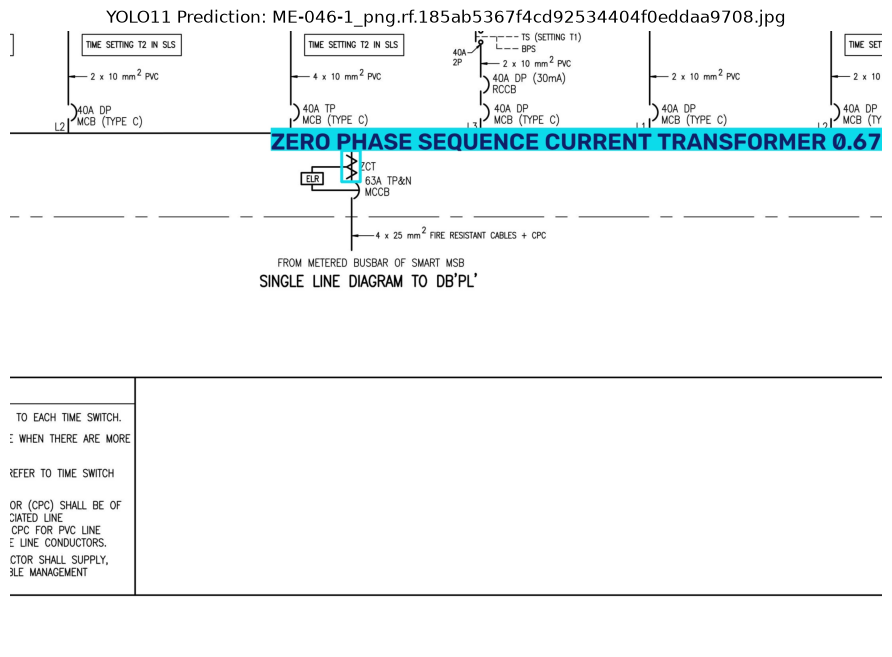

All prediction images saved in: D:\HOSHO\Model Testing\results\yolo\test_visual_predictions


In [ ]:
test_img_dir = base_dir / "SLD_YOLO_Dataset" / "images" / "test"
pred_dir = output_dir / "test_visual_predictions"

print("Generating test predictions...")
preds = model.predict(
    source=str(test_img_dir),
    save=True,
    project=str(output_dir),
    name="test_visual_predictions",
    device=device,
    conf=0.25,
    exist_ok=True
)

# Display sample predicted image inside notebook
pred_images = list((output_dir / "test_visual_predictions").glob("*.jpg"))
if pred_images:
    sample_img_path = str(pred_images[0])
    img = cv2.imread(sample_img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"YOLO11 Prediction: {Path(sample_img_path).name}")
    plt.axis('off')
    plt.show()
    print(f"All prediction images saved in: {output_dir / 'test_visual_predictions'}")